# Regenerate figures

Run the cells from top to bottom. Each code cell performs one focused action: setup, data loading, one chart, or one export step.

In [32]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

In [33]:
ROOT = Path.cwd().parent if Path.cwd().name == 'code' else Path.cwd()
ART = ROOT / 'artifacts'
FIG = ROOT / 'figures'
FIG.mkdir(exist_ok=True)
CYTO = FIG / 'cytoscape'
CYTO.mkdir(exist_ok=True)

In [34]:
INK = '#1b2a36'
CLAY = '#c1666b'
BRASS = '#c4a35a'
MOSS = '#4a7c59'
DUSK = '#5c4d7a'
PAPER = '#f6f1e8'
GRID = '#d9d0c3'
MUTED = '#6b6358'
PALETTE = [INK, CLAY, BRASS, MOSS, DUSK, '#2f6f7a']
THEME_COLORS = {'T': '#2f6f7a', 'E': MOSS, 'S': BRASS, 'V': DUSK}

In [35]:
sns.set_theme(
    style='whitegrid',
    context='talk',
    font='DejaVu Serif',
    rc={
        'axes.facecolor': PAPER, 'figure.facecolor': PAPER,
        'axes.edgecolor': INK, 'axes.labelcolor': INK,
        'xtick.color': INK, 'ytick.color': INK, 'text.color': INK,
        'grid.color': GRID, 'grid.linewidth': 0.6,
        'axes.titleweight': 'bold', 'axes.titlesize': 14,
        'axes.labelsize': 12, 'figure.dpi': 140,
        'savefig.dpi': 240, 'savefig.facecolor': PAPER,
        'font.family': 'DejaVu Serif',
    },
)

In [36]:
def polish(ax, title, xlabel=None, ylabel=None):
    ax.set_title(title, pad=12, color=INK)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(INK)
    ax.spines['bottom'].set_color(INK)

In [37]:
kept = pd.read_csv(ART / 'encoded_respondents.csv')
item_cols = [c for c in kept.columns if c not in ('respondent_id', 'completeness')]
flat = kept[item_cols].stack().dropna()
value_counts = flat.value_counts().sort_index()
themes = {
    'T': [c for c in item_cols if c.startswith('T')],
    'E': [c for c in item_cols if c.startswith('E')],
    'S': [c for c in item_cols if c.startswith('S')],
    'V': [c for c in item_cols if c.startswith('V')],
}

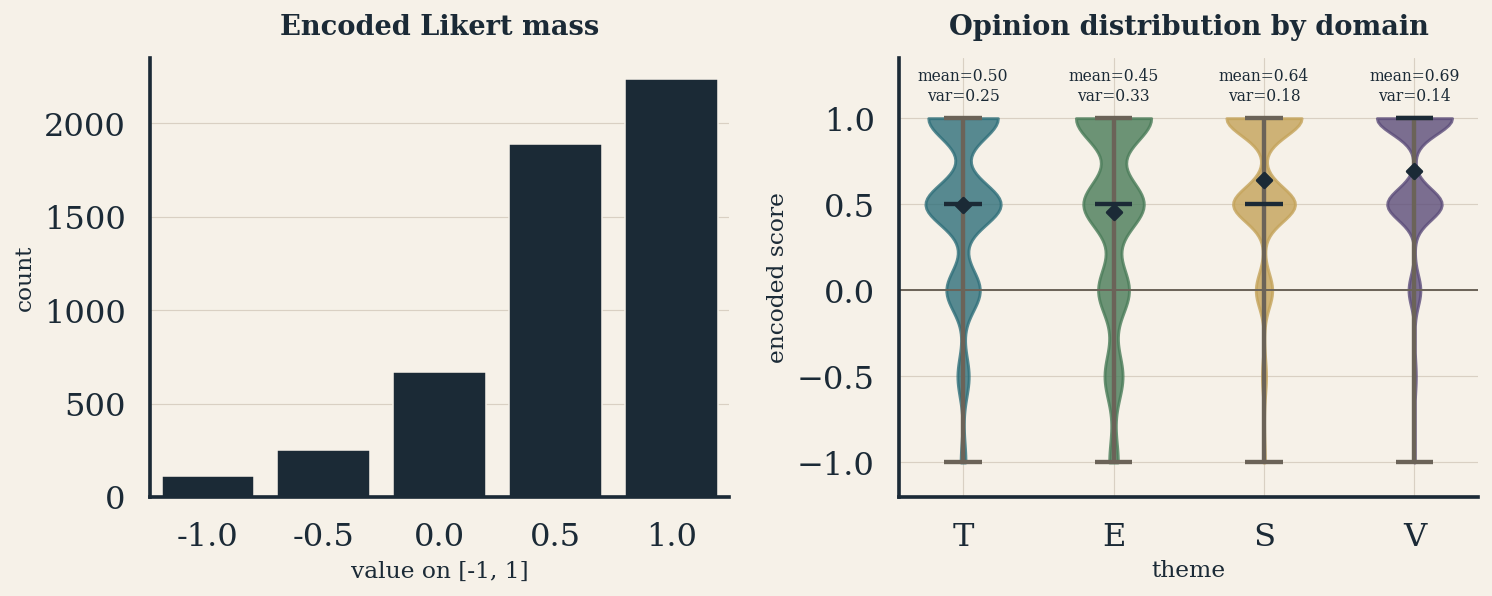

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
sns.barplot(x=value_counts.index.astype(str), y=value_counts.values, ax=axes[0], color=INK, saturation=1)
polish(axes[0], 'Encoded Likert mass', 'value on [-1, 1]', 'count')
for patch in axes[0].patches:
    patch.set_edgecolor(PAPER)
    patch.set_linewidth(0.8)
theme_values = [kept[cols].stack().dropna().to_numpy() for cols in themes.values()]
theme_means = [float(np.mean(values)) for values in theme_values]
theme_variances = [float(np.var(values)) for values in theme_values]
violinplot = axes[1].violinplot(
    theme_values,
    showmeans=False,
    showmedians=True,
    showextrema=True,
)
for body, theme in zip(violinplot['bodies'], themes):
    body.set_facecolor(THEME_COLORS[theme])
    body.set_edgecolor(THEME_COLORS[theme])
    body.set_alpha(0.8)
violinplot['cmedians'].set_color(INK)
violinplot['cmins'].set_color(MUTED)
violinplot['cmaxes'].set_color(MUTED)
violinplot['cbars'].set_color(MUTED)
axes[1].scatter(
    range(1, len(theme_means) + 1),
    theme_means,
    marker='D',
    color=INK,
    s=28,
    zorder=3,
)
for index, theme in enumerate(themes):
    axes[1].text(
        index + 1,
        1.08,
        f'mean={theme_means[index]:.2f}\nvar={theme_variances[index]:.2f}',
        ha='center',
        va='bottom',
        fontsize=8,
        color=INK,
    )
axes[1].set_xticks(range(1, len(themes) + 1), list(themes.keys()))
axes[1].set_ylim(-1.2, 1.35)
axes[1].axhline(0, color=MUTED, lw=1)
polish(axes[1], 'Opinion distribution by domain', 'theme', 'encoded score')
fig.tight_layout()
fig.savefig(FIG / 'eda_likert_and_themes.png', bbox_inches='tight')
plt.show()
plt.close(fig)

## Rebuild respondent similarity artifacts

These cells recreate the matrix and threshold files used by the similarity and threshold figures.

In [39]:
X = kept[item_cols].to_numpy(dtype=float)
respondent_ids = kept['respondent_id'].astype(str).tolist()
n_respondents = len(respondent_ids)

similarity = np.full((n_respondents, n_respondents), np.nan)
overlap = np.zeros((n_respondents, n_respondents), dtype=int)

print('matrix shape:', similarity.shape)
print('respondents:', n_respondents)
print('items:', len(item_cols))

matrix shape: (87, 87)
respondents: 87
items: 60


In [40]:
for i in range(n_respondents):
    for j in range(i + 1, n_respondents):
        jointly_answered = np.isfinite(X[i]) & np.isfinite(X[j])
        n_joint = int(jointly_answered.sum())
        overlap[i, j] = overlap[j, i] = n_joint
        if n_joint < 20:
            continue
        disagreement = np.abs(X[i, jointly_answered] - X[j, jointly_answered]).sum()
        similarity[i, j] = similarity[j, i] = n_joint - disagreement

similarity_values = similarity[np.triu_indices(n_respondents, k=1)]
similarity_values = similarity_values[np.isfinite(similarity_values)]
print('valid respondent pairs:', len(similarity_values))
print(pd.Series(similarity_values).describe())

valid respondent pairs: 3741
count    3741.000000
mean       33.711441
std         7.454725
min        -3.000000
25%        30.000000
50%        34.500000
75%        38.500000
max        52.000000
dtype: float64


In [41]:
np.save(ART / 'similarity_matrix.npy', similarity)
np.save(ART / 'overlap_matrix.npy', overlap)
pd.DataFrame(similarity, index=respondent_ids, columns=respondent_ids).to_csv(ART / 'similarity_matrix.csv')
pd.DataFrame(overlap, index=respondent_ids, columns=respondent_ids).to_csv(ART / 'overlap_matrix.csv')
print('wrote similarity_matrix.npy/csv and overlap_matrix.npy/csv')

wrote similarity_matrix.npy/csv and overlap_matrix.npy/csv


In [42]:
threshold_records = []
for candidate_theta in sorted(set(similarity_values), reverse=True):
    threshold_graph = nx.Graph()
    threshold_graph.add_nodes_from(respondent_ids)
    upper_i, upper_j = np.triu_indices(n_respondents, k=1)
    for i, j in zip(upper_i, upper_j):
        score = similarity[i, j]
        if np.isfinite(score) and score >= candidate_theta:
            threshold_graph.add_edge(respondent_ids[i], respondent_ids[j], weight=float(score))
    if threshold_graph.number_of_edges():
        largest_component = max(nx.connected_components(threshold_graph), key=len)
        giant_size = len(largest_component)
    else:
        giant_size = 1
    threshold_records.append({
        'theta': float(candidate_theta),
        'n_nodes': threshold_graph.number_of_nodes(),
        'n_edges': threshold_graph.number_of_edges(),
        'giant_frac': giant_size / n_respondents,
        'giant_size': giant_size,
    })

threshold_scan = pd.DataFrame(threshold_records)
target_giant_fraction = 0.80
eligible = threshold_scan[(threshold_scan['giant_frac'] >= target_giant_fraction) & (threshold_scan['n_edges'] > 0)]
chosen_theta = float(eligible.iloc[0]['theta']) if not eligible.empty else float(threshold_scan.loc[threshold_scan['giant_frac'].idxmax(), 'theta'])
threshold_scan.to_csv(ART / 'threshold_scan.csv', index=False)
(ART / 'chosen_theta.json').write_text(json.dumps({'theta': chosen_theta, 'giant_frac_target': target_giant_fraction}, indent=2))
print('chosen theta:', chosen_theta)
print('wrote threshold_scan.csv and chosen_theta.json')

chosen theta: 41.5
wrote threshold_scan.csv and chosen_theta.json


In [43]:
similarity = np.load(ART / 'similarity_matrix.npy')
similarity_values = similarity[np.triu_indices(similarity.shape[0], k=1)]
similarity_values = similarity_values[np.isfinite(similarity_values)]
theta = json.loads((ART / 'chosen_theta.json').read_text())['theta']

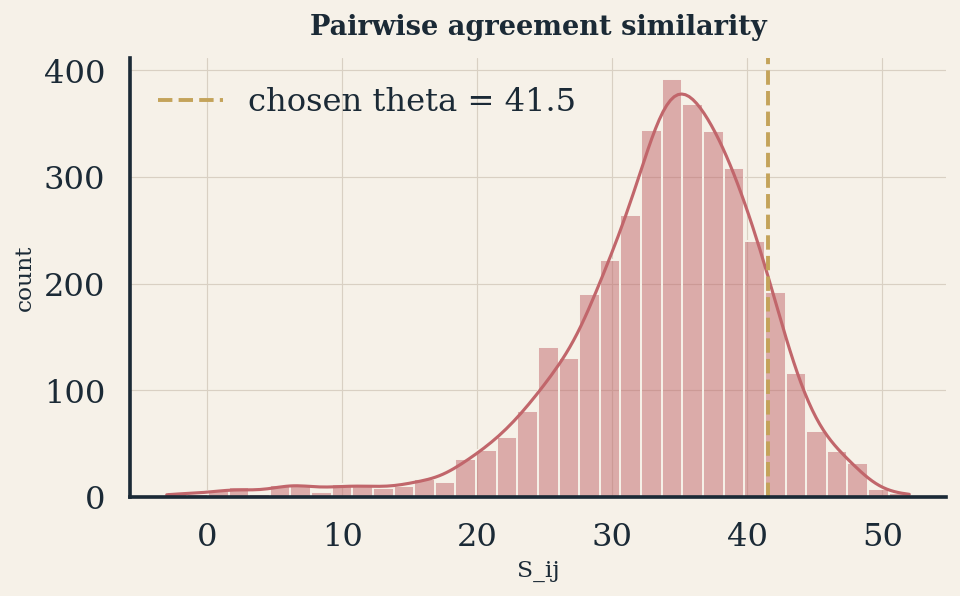

In [44]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
sns.histplot(similarity_values, bins=36, ax=ax, color=CLAY, edgecolor=PAPER, kde=True, line_kws={'color': INK, 'lw': 1.6})
ax.axvline(theta, color=BRASS, ls='--', lw=2, label=f'chosen theta = {theta}')
polish(ax, 'Pairwise agreement similarity', 'S_ij', 'count')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG / 'similarity_distribution.png', bbox_inches='tight')
plt.show()
plt.close(fig)

In [45]:
threshold_scan = pd.read_csv(ART / 'threshold_scan.csv').sort_values('theta')
threshold_scan = threshold_scan.iloc[::max(1, len(threshold_scan) // 250)]
theta = json.loads((ART / 'chosen_theta.json').read_text())['theta']
target = json.loads((ART / 'chosen_theta.json').read_text()).get('giant_frac_target', 0.8)

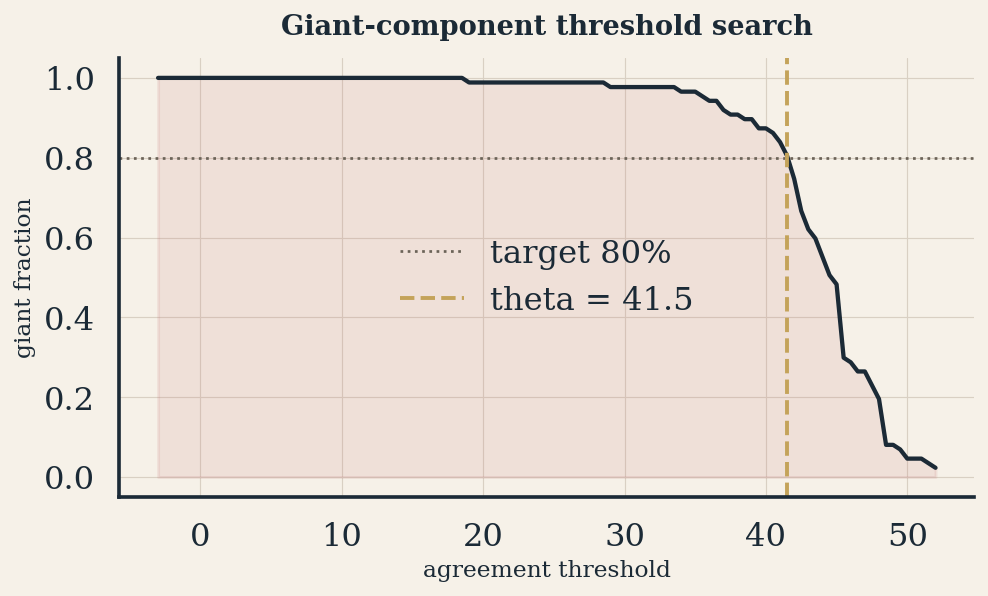

In [46]:
fig, ax = plt.subplots(figsize=(7.4, 4.6))
sns.lineplot(data=threshold_scan, x='theta', y='giant_frac', ax=ax, color=INK, lw=2.2)
ax.fill_between(threshold_scan['theta'], threshold_scan['giant_frac'], alpha=0.12, color=CLAY)
ax.axhline(target, color=MUTED, ls=':', lw=1.4, label=f'target {target:.0%}')
ax.axvline(theta, color=BRASS, ls='--', lw=2, label=f'theta = {theta}')
polish(ax, 'Giant-component threshold search', 'agreement threshold', 'giant fraction')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG / 'threshold_giant_component.png', bbox_inches='tight')
plt.show()
plt.close(fig)

In [47]:
agent_graph = nx.read_graphml(ART / 'agent_network.graphml')
degree_data = pd.DataFrame({'degree': [degree for _, degree in agent_graph.degree()]})

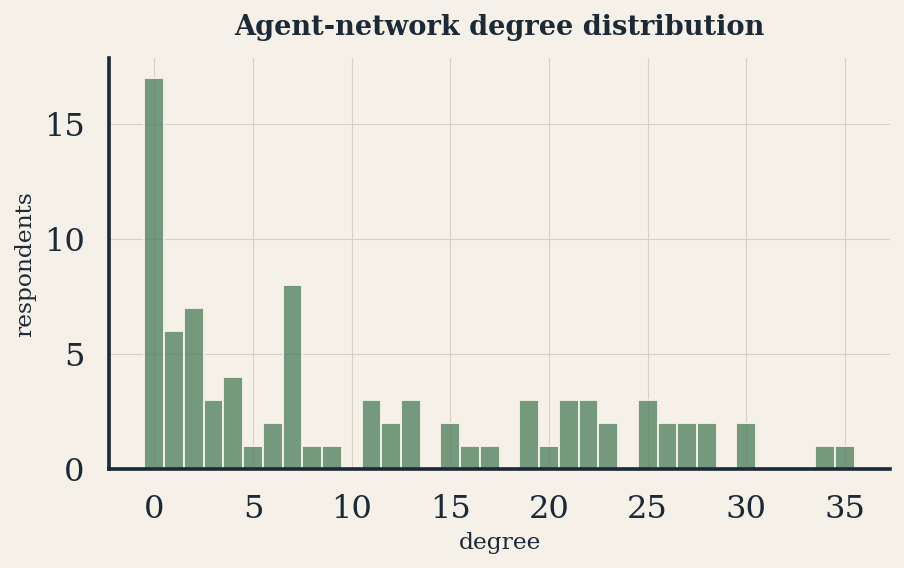

In [48]:
fig, ax = plt.subplots(figsize=(6.8, 4.4))
sns.histplot(data=degree_data, x='degree', discrete=True, ax=ax, color=MOSS, edgecolor=PAPER)
polish(ax, 'Agent-network degree distribution', 'degree', 'respondents')
fig.tight_layout()
fig.savefig(FIG / 'agent_degree_distribution.png', bbox_inches='tight')
plt.show()
plt.close(fig)

In [49]:
profile = pd.read_csv(ART / 'community_theme_profiles.csv')
if 'louvain' not in profile.columns and 'Unnamed: 0' in profile.columns:
    profile = profile.rename(columns={'Unnamed: 0': 'louvain'})
if 'size' in profile.columns:
    profile = profile[profile['size'] >= 3].copy()
long_profile = profile.melt(
    id_vars=['louvain', 'size'],
    value_vars=['mean_T', 'mean_E', 'mean_S', 'mean_V'],
    var_name='theme',
    value_name='mean_score',
)
long_profile['theme'] = long_profile['theme'].str.replace('mean_', '', regex=False)
community_sizes = profile.set_index('louvain')['size'].astype(int).to_dict()
long_profile['community_label'] = long_profile['louvain'].map(
    lambda community_id: f'C{community_id} (n={community_sizes[community_id]})'
)

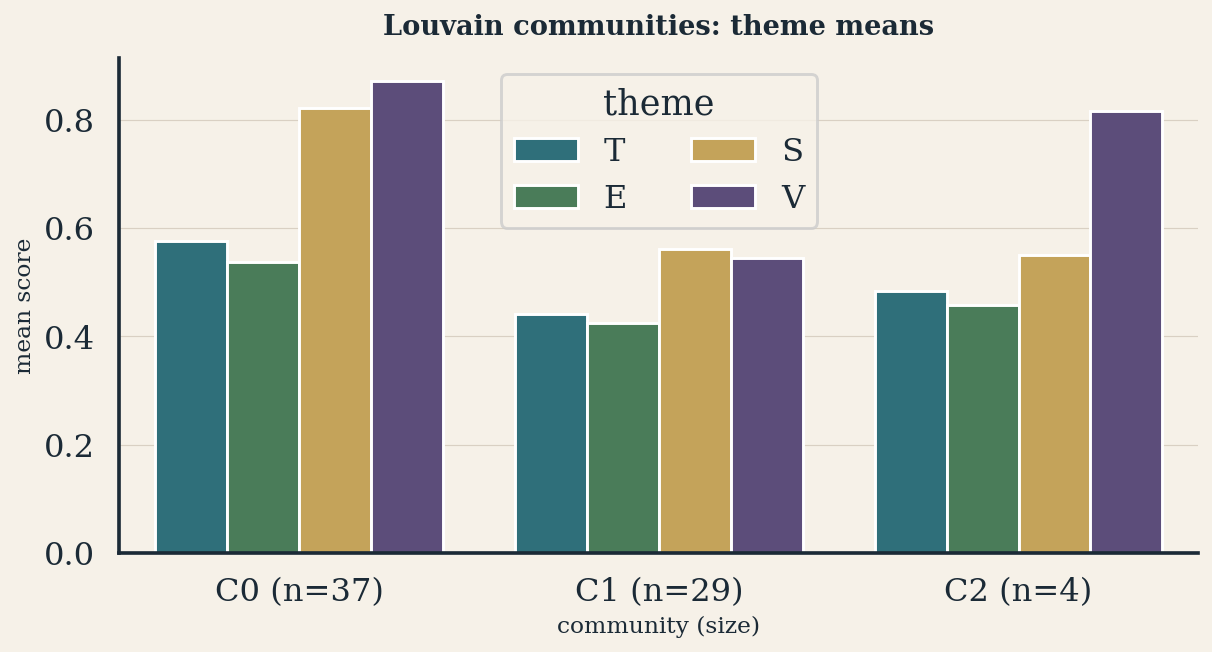

In [50]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=long_profile, x='community_label', y='mean_score', hue='theme', palette=THEME_COLORS, ax=ax, saturation=1)
ax.axhline(0, color=MUTED, lw=1)
polish(ax, 'Louvain communities: theme means', 'community (size)', 'mean score')
ax.tick_params(axis='x')
ax.legend(title='theme', frameon=True, ncols=2)
fig.tight_layout()
fig.savefig(FIG / 'community_theme_profiles.png', bbox_inches='tight')
plt.show()
plt.close(fig)

In [51]:
attitude_graph = nx.read_graphml(ART / 'attitude_network.graphml')
attitude_nodes = sorted(attitude_graph.nodes())
attitude_matrix = pd.DataFrame(0.0, index=attitude_nodes, columns=attitude_nodes)
for source, target, data in attitude_graph.edges(data=True):
    weight = float(data.get('weight', 0.0))
    attitude_matrix.loc[source, target] = weight
    attitude_matrix.loc[target, source] = weight
keep_nodes = attitude_matrix.sum(axis=1) > 0
attitude_matrix = attitude_matrix.loc[keep_nodes, keep_nodes]

In [52]:
top_attitude_edges = pd.DataFrame(
    [
        {
            'question_1': str(attitude_graph.nodes[source].get('full_label', source)),
            'question_2': str(attitude_graph.nodes[target].get('full_label', target)),
            'co_endorsement_weight': float(data.get('weight', 0.0)),
            'respondents': int(data.get('n_respondents', 0)),
        }
        for source, target, data in attitude_graph.edges(data=True)
    ]
).sort_values('co_endorsement_weight', ascending=False).head(20).reset_index(drop=True)
top_attitude_edges.index += 1
display(top_attitude_edges)
top_attitude_edges.to_csv(ART / 'top_20_attitude_edges.csv', index_label='rank')

,question_1,question_2,co_endorsement_weight,respondents
1,E11. University curricula should be updated mo...,E15. Continuous learning and skill development...,63.25,87
2,E15. Continuous learning and skill development...,V13. Companies should be held accountable for ...,62.00,85
3,E15. Continuous learning and skill development...,S05. Individuals should have greater control o...,61.75,87
4,E14. Strong collaborations between universitie...,E15. Continuous learning and skill development...,61.50,87
5,V09. Products should be designed to encourage ...,V13. Companies should be held accountable for ...,61.25,85
6,E15. Continuous learning and skill development...,V09. Products should be designed to encourage ...,61.00,85
7,S05. Individuals should have greater control o...,V13. Companies should be held accountable for ...,60.50,85
8,E10. Universities should prioritize innovation...,E15. Continuous learning and skill development...,60.50,87
9,E15. Continuous learning and skill development...,S11. People should be free to express differin...,60.00,87
10,E15. Continuous learning and skill development...,V14. International cooperation is necessary to...,59.50,85


/home/vishak/.local/lib/python3.13/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/vishak/.local/lib/python3.13/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


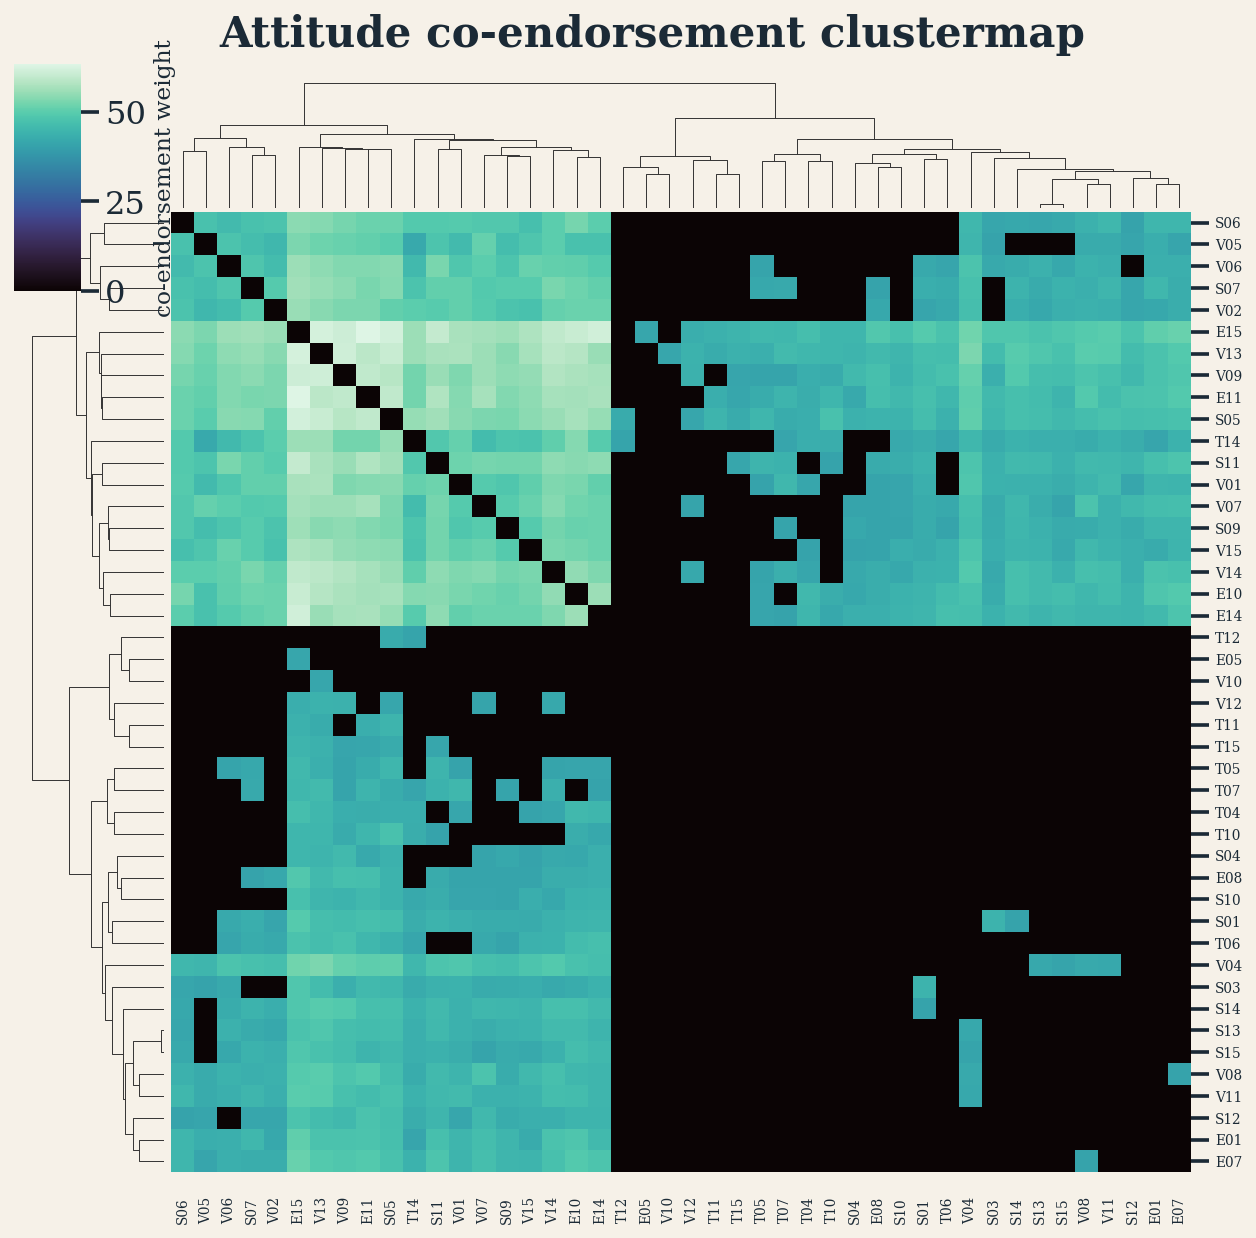

In [53]:
if attitude_matrix.shape[0] >= 4:
    clustermap = sns.clustermap(
        attitude_matrix, cmap='mako', figsize=(9.5, 9.0),
        dendrogram_ratio=0.12, linewidths=0.0,
        xticklabels=True, yticklabels=True,
        cbar_kws={'label': 'co-endorsement weight'},
    )
    clustermap.fig.patch.set_facecolor(PAPER)
    clustermap.ax_heatmap.set_facecolor(PAPER)
    clustermap.ax_heatmap.tick_params(labelsize=7, colors=INK)
    clustermap.fig.suptitle('Attitude co-endorsement clustermap', color=INK, fontweight='bold', y=1.02)
    clustermap.savefig(FIG / 'attitude_clustermap.png', dpi=240, bbox_inches='tight', facecolor=PAPER)
    plt.show()
    plt.close('all')

## Clustermap with full question text

Same co-endorsement matrix and hierarchical clustering as above, but axis ticks show the full survey questions (not only codes like `T14`). Saved as `figures/attitude_clustermap_questions.png`.

/home/vishak/.local/lib/python3.13/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/vishak/.local/lib/python3.13/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


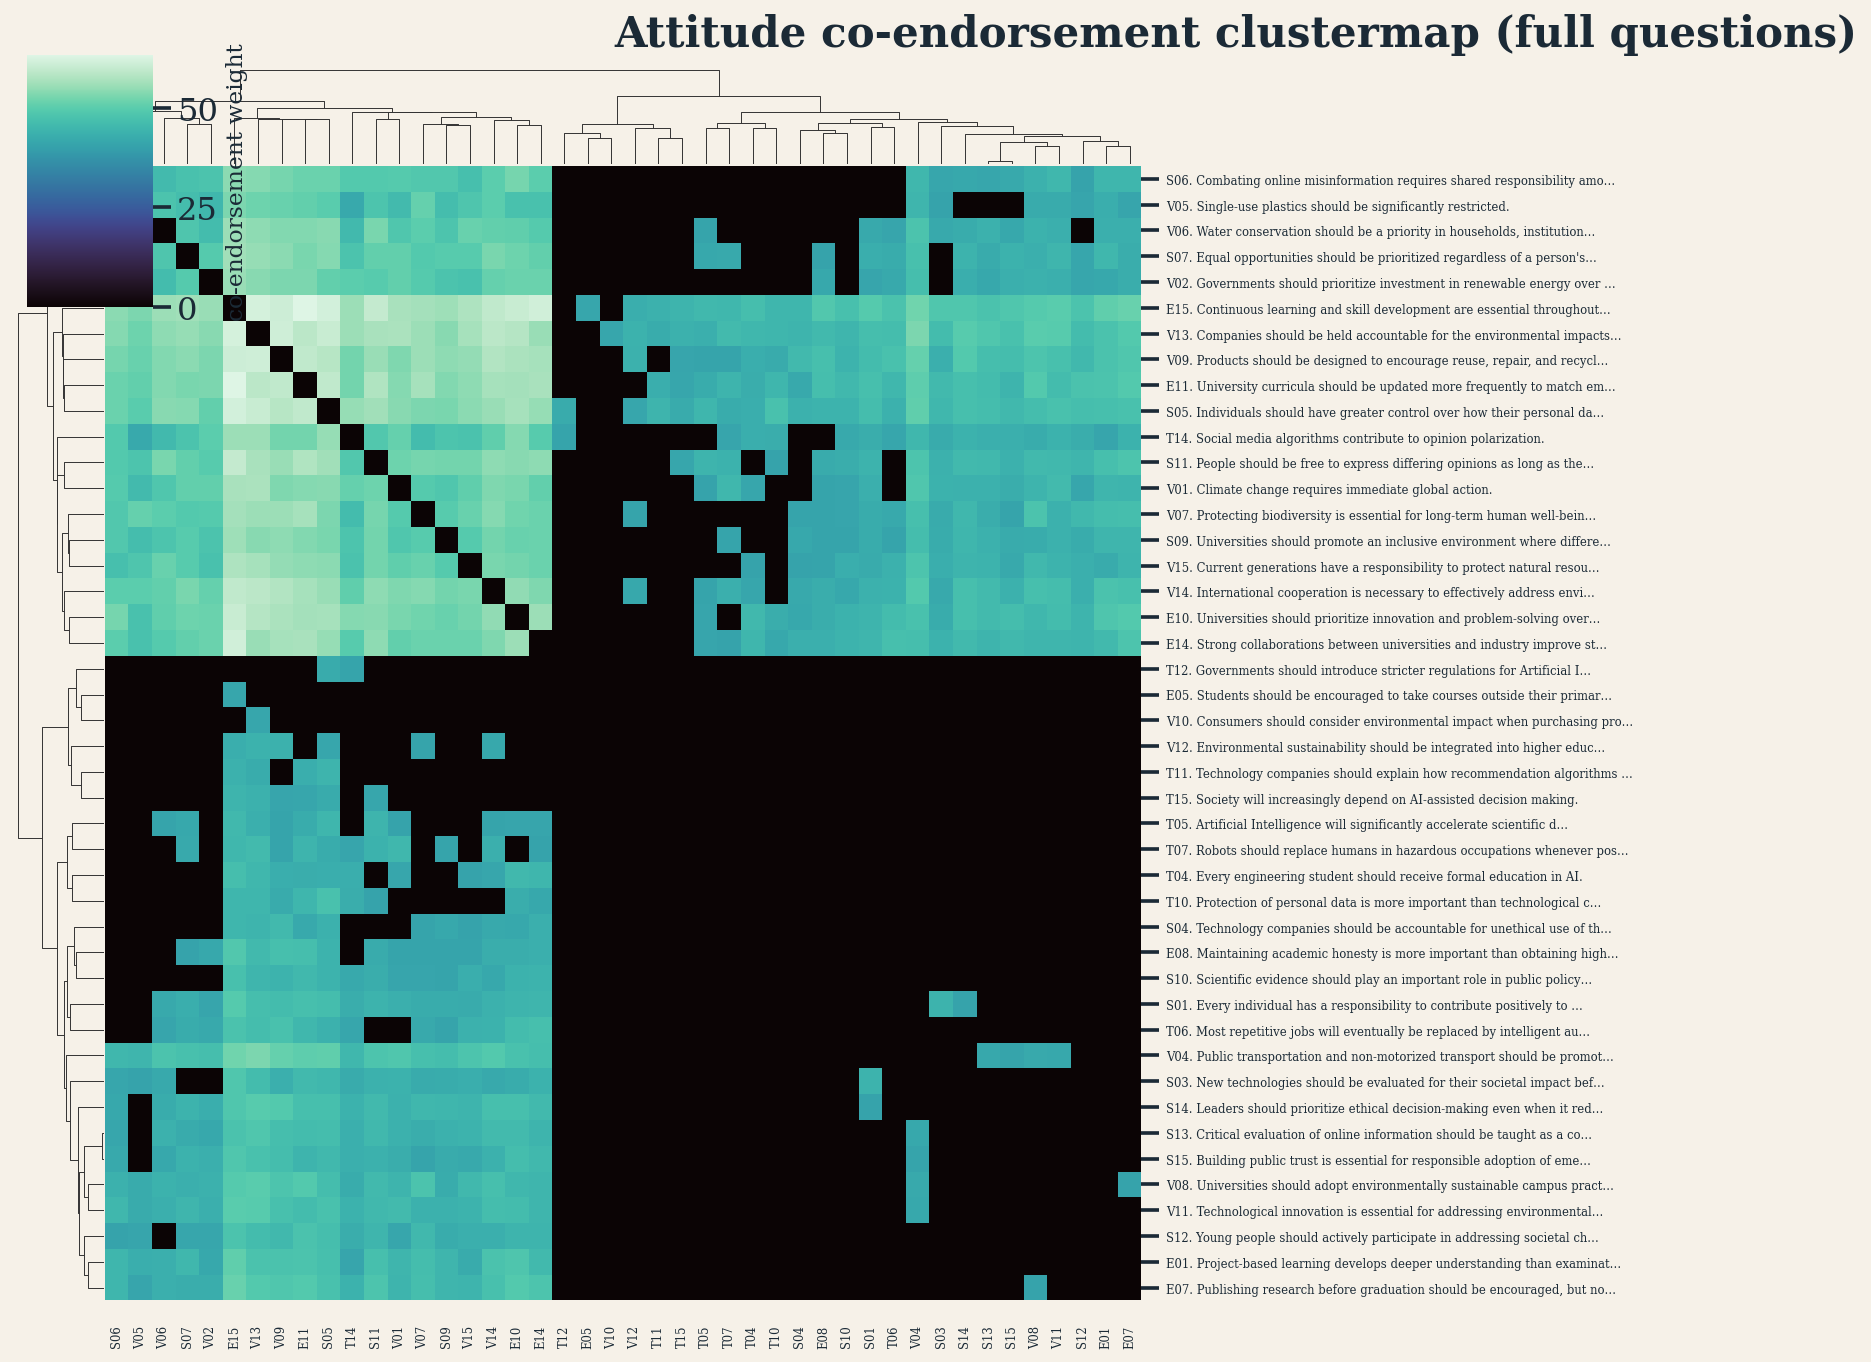

,cluster_position,item,full_question
0,1,S06,S06. Combating online misinformation requires ...
1,2,V05,V05. Single-use plastics should be significant...
2,3,V06,V06. Water conservation should be a priority i...
3,4,S07,S07. Equal opportunities should be prioritized...
4,5,V02,V02. Governments should prioritize investment ...
5,6,E15,E15. Continuous learning and skill development...
6,7,V13,V13. Companies should be held accountable for ...
7,8,V09,V09. Products should be designed to encourage ...
8,9,E11,E11. University curricula should be updated mo...
9,10,S05,S05. Individuals should have greater control o...


wrote /home/vishak/IIITH-IV-I/dpcn/dpcn-a1-opinion-network-team34/figures/attitude_clustermap_questions.png
wrote /home/vishak/IIITH-IV-I/dpcn/dpcn-a1-opinion-network-team34/artifacts/attitude_clustermap_question_order.csv


In [65]:
# Build short-code -> full question map from GraphML node attributes (fallback: item_stats.csv)
item_stats = pd.read_csv(ART / 'item_stats.csv')
code_to_question = {
    str(row['item']): str(row['full_label'])
    for _, row in item_stats.iterrows()
}
for node, data in attitude_graph.nodes(data=True):
    full = data.get('full_label')
    if full:
        code_to_question[str(node)] = str(full)

# Truncate long labels so the figure stays readable
def question_tick(code, max_len=72):
    text = code_to_question.get(str(code), str(code))
    text = ' '.join(text.split())  # collapse whitespace
    if len(text) > max_len:
        return text[: max_len - 1] + '…'
    return text

labeled_matrix = attitude_matrix.copy()
labeled_matrix.index = [question_tick(c) for c in labeled_matrix.index]
# labeled_matrix.columns = [question_tick(c) for c in labeled_matrix.columns]

if labeled_matrix.shape[0] >= 4:
    clustermap_q = sns.clustermap(
        labeled_matrix,
        cmap='mako',
        figsize=(18, 10),
        dendrogram_ratio=0.08,
        linewidths=0.0,
        xticklabels=True,
        yticklabels=True,
        cbar_kws={'label': 'co-endorsement weight'},
        method='average',
        metric='euclidean',
    )
    clustermap_q.fig.patch.set_facecolor(PAPER)
    clustermap_q.ax_heatmap.set_facecolor(PAPER)
    clustermap_q.ax_heatmap.tick_params(axis='x', labelsize=6, colors=INK, labelrotation=90)
    clustermap_q.ax_heatmap.tick_params(axis='y', labelsize=6, colors=INK)
    clustermap_q.fig.suptitle(
        'Attitude co-endorsement clustermap (full questions)',
        color=INK,
        fontweight='bold',
        y=1.01,
    )
    out_path = FIG / 'attitude_clustermap_questions.png'
    clustermap_q.savefig(out_path, dpi=240, bbox_inches='tight', facecolor=PAPER)
    plt.show()
    plt.close('all')

    # Also write the leaf order with full questions for the report / appendix
    from scipy.cluster.hierarchy import leaves_list

    leaf_order = leaves_list(clustermap_q.dendrogram_row.linkage)
    order_codes = list(attitude_matrix.index[leaf_order])
    order_df = pd.DataFrame(
        {
            'cluster_position': range(1, len(order_codes) + 1),
            'item': order_codes,
            'full_question': [code_to_question.get(c, c) for c in order_codes],
        }
    )
    order_df.to_csv(ART / 'attitude_clustermap_question_order.csv', index=False)
    display(order_df)
    print('wrote', out_path)
    print('wrote', ART / 'attitude_clustermap_question_order.csv')


## Attitude network: degree-scaled layout and eigenvector centrality

We had **not** computed eigenvector centrality before. These cells:

1. redraw the attitude co-endorsement network with **node size proportional to degree**
2. compute **eigenvector centrality** (on the giant component; isolates get 0) and plot a bar chart

Outputs: `figures/attitude_network_by_degree.png`, `figures/attitude_eigenvector_centrality.png`, `artifacts/attitude_centrality.csv`.

In [ ]:
# Degree-scaled attitude co-endorsement network + eigenvector centrality
G_att = attitude_graph.copy()
degrees = dict(G_att.degree())
max_deg = max(degrees.values()) if degrees else 1

# Eigenvector centrality is well-behaved on a connected graph: use giant component
components = sorted(nx.connected_components(G_att), key=len, reverse=True)
giant_nodes = components[0] if components else set()
G_giant_att = G_att.subgraph(giant_nodes).copy()
eig_giant = nx.eigenvector_centrality_numpy(G_giant_att, weight='weight')
eig = {n: float(eig_giant.get(n, 0.0)) for n in G_att.nodes()}

centrality_df = pd.DataFrame(
    {
        'item': list(G_att.nodes()),
        'theme': [G_att.nodes[n].get('theme', str(n)[0]) for n in G_att.nodes()],
        'full_label': [G_att.nodes[n].get('full_label', str(n)) for n in G_att.nodes()],
        'degree': [degrees[n] for n in G_att.nodes()],
        'eigenvector_centrality': [eig[n] for n in G_att.nodes()],
    }
).sort_values('eigenvector_centrality', ascending=False)
centrality_df.to_csv(ART / 'attitude_centrality.csv', index=False)
display(centrality_df.head(15))

# --- Network plot: node size ~ degree ---
pos = nx.spring_layout(G_att, weight='weight', seed=42, k=1.8 / np.sqrt(max(G_att.number_of_nodes(, iterations=200), 1)))
node_colors = [THEME_COLORS.get(G_att.nodes[n].get('theme', 'T'), INK) for n in G_att.nodes()]
node_sizes = [80 + 28 * degrees[n] for n in G_att.nodes()]
weights = np.array([float(d.get('weight', 1.0)) for *_, d in G_att.edges(data=True)], dtype=float)
if len(weights):
    widths = 0.3 + 2.0 * (weights - weights.min()) / (weights.max() - weights.min() + 1e-9)
else:
    widths = 1.0

fig, ax = plt.subplots(figsize=(11, 8.5))
fig.patch.set_facecolor(PAPER)
ax.set_facecolor(PAPER)
nx.draw_networkx_edges(G_att, pos, ax=ax, width=widths, alpha=0.28, edge_color='#8a8074')
nx.draw_networkx_nodes(
    G_att, pos, ax=ax,
    node_color=node_colors, node_size=node_sizes,
    linewidths=0.6, edgecolors=PAPER, alpha=0.95,
)
nx.draw_networkx_labels(G_att, pos, ax=ax, font_size=7, font_color=INK, font_family='DejaVu Serif')
polish(ax, 'Attitude co-endorsement network (node size = degree)')
ax.axis('off')
handles = [mpatches.Patch(color=c, label=t) for t, c in THEME_COLORS.items()]
ax.legend(handles=handles, loc='best', frameon=False, title='theme')
fig.tight_layout()
fig.savefig(FIG / 'attitude_network_by_degree.png', dpi=240, bbox_inches='tight', facecolor=PAPER)
plt.show()
plt.close(fig)

# --- Bar plot: eigenvector centrality ---
plot_df = centrality_df.sort_values('eigenvector_centrality', ascending=True)
fig, ax = plt.subplots(figsize=(9, 10))
sns.barplot(
    data=plot_df, y='item', x='eigenvector_centrality', hue='theme',
    dodge=False, palette=THEME_COLORS, ax=ax, saturation=1,
)
polish(ax, 'Attitude network eigenvector centrality', 'eigenvector centrality', None)
ax.legend(title='theme', frameon=False, loc='lower right')
fig.tight_layout()
fig.savefig(FIG / 'attitude_eigenvector_centrality.png', dpi=240, bbox_inches='tight', facecolor=PAPER)
plt.show()
plt.close(fig)

print('wrote', FIG / 'attitude_network_by_degree.png')
print('wrote', FIG / 'attitude_eigenvector_centrality.png')
print('wrote', ART / 'attitude_centrality.csv')
print(f'giant component size for eigenvector: {len(giant_nodes)} / {G_att.number_of_nodes()} nodes')



In [55]:
importance = pd.read_csv(ART / 'item_importance.csv').head(15)
contested = pd.read_csv(ART / 'item_stats.csv').head(15)

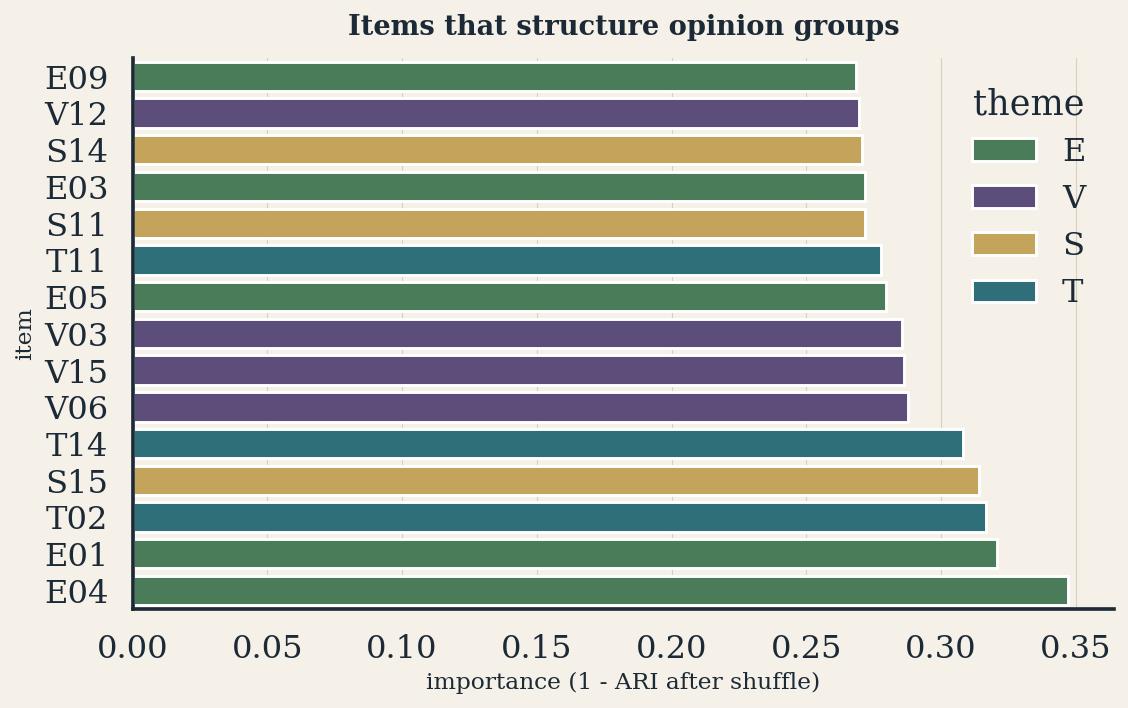

In [56]:
fig, ax = plt.subplots(figsize=(8.4, 5.4))
sns.barplot(data=importance.sort_values('importance'), y='item', x='importance', hue='theme', dodge=False, palette=THEME_COLORS, ax=ax, saturation=1)
polish(ax, 'Items that structure opinion groups', 'importance (1 - ARI after shuffle)')
ax.legend(title='theme', frameon=False, loc='upper right')
fig.tight_layout()
fig.savefig(FIG / 'item_importance_top15.png', bbox_inches='tight')
plt.show()
plt.close(fig)

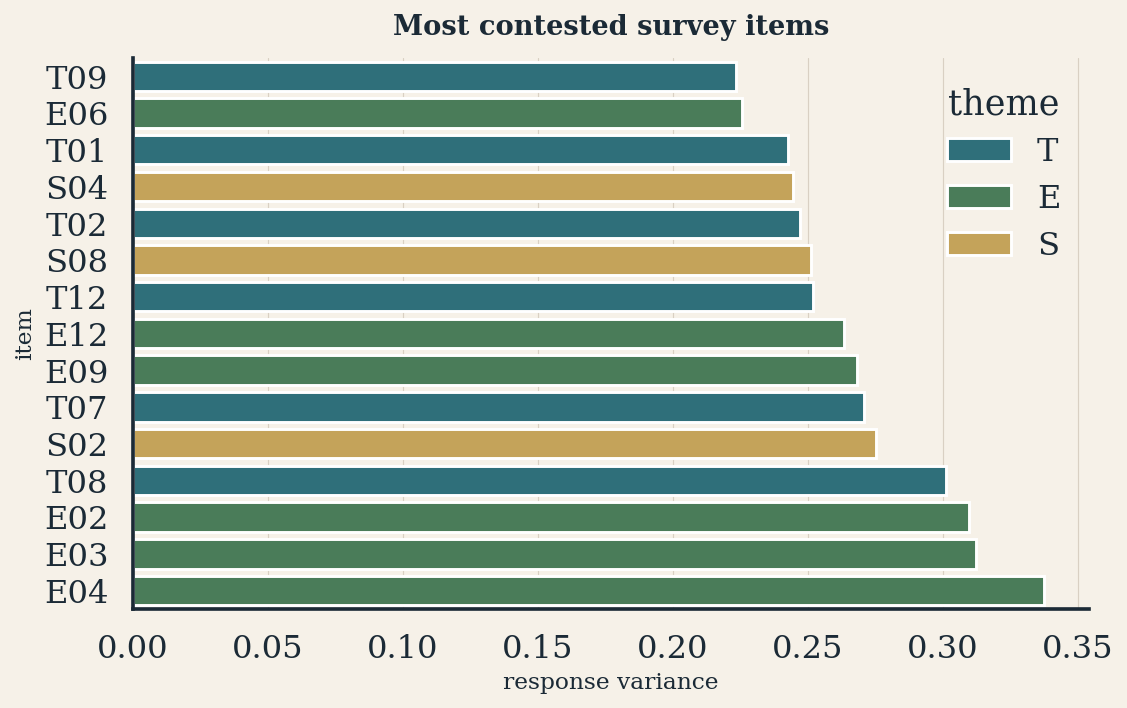

In [57]:
fig, ax = plt.subplots(figsize=(8.4, 5.4))
sns.barplot(data=contested.sort_values('variance'), y='item', x='variance', hue='theme', dodge=False, palette=THEME_COLORS, ax=ax, saturation=1)
polish(ax, 'Most contested survey items', 'response variance')
ax.legend(title='theme', frameon=False, loc='upper right')
fig.tight_layout()
fig.savefig(FIG / 'contested_items_variance.png', bbox_inches='tight')
plt.show()
plt.close(fig)

## Cytoscape exports

The remaining cells export the interactive network HTML files and static fallback PNGs.

In [58]:
def graph_to_cyto_elements(
    graph,
    node_color_attr,
    color_map,
    label_communities=False,
    edge_heatmap=False,
):
    elements = []
    edge_weights = [float(data.get('weight', 1.0)) for _, _, data in graph.edges(data=True)]
    min_weight = min(edge_weights) if edge_weights else 0.0
    max_weight = max(edge_weights) if edge_weights else 1.0
    edge_cmap = plt.cm.viridis
    for node, data in graph.nodes(data=True):
        key = data.get(node_color_attr, 'default')
        if isinstance(key, str) and key.lstrip('-').isdigit():
            key = int(key)
        color = color_map.get(key, color_map.get(str(key), INK))
        label = f'C{key}' if label_communities else str(node)
        question = str(data.get('full_label', data.get('question', node)))
        deg = int(graph.degree(node))
        # Cytoscape pixel size: base + scale * degree
        size = 14 + 2.2 * deg
        elements.append({
            'data': {
                'id': str(node),
                'label': label,
                'question': question,
                'color': color,
                'degree': deg,
                'size': size,
                **{k: '' if v is None else str(v) for k, v in data.items()},
            }
        })
    for source, target, data in graph.edges(data=True):
        weight = float(data.get('weight', 1.0))
        if edge_heatmap:
            normalized = (weight - min_weight) / (max_weight - min_weight + 1e-12)
            edge_color = '#%02x%02x%02x' % tuple(
                int(channel * 255) for channel in edge_cmap(normalized)[:3]
            )
        else:
            edge_color = '#8a8074'
        elements.append({
            'data': {
                'id': f'{source}_{target}',
                'source': str(source),
                'target': str(target),
                'weight': weight,
                'color': edge_color,
            }
        })
    return elements


In [59]:
def write_cytoscape_html(name, elements, title, node_size=22, show_labels=True, weight_max=80.0, fixed_screen_nodes=True, hover_questions=False):
    html_path = CYTO / f'{name}.html'
    edge_weights = [
        float(element['data']['weight'])
        for element in elements
        if 'weight' in element['data']
    ]
    edge_min = min(edge_weights) if edge_weights else 0.0
    edge_max = max(edge_weights) if edge_weights else float(weight_max)
    payload = {
        'title': title,
        'elements': elements,
        'nodeSize': node_size * 1.3,
        'showLabels': show_labels,
        'weightMax': weight_max,
        'edgeMin': edge_min,
        'edgeMax': edge_max,
        'fixedScreenNodes': fixed_screen_nodes,
        'hoverQuestions': hover_questions,
        'bg': PAPER,
        'edge': '#8a8074',
    }
    html = f'''<!DOCTYPE html>
<html><head><meta charset="utf-8"/><title>LOADING</title>
<script src="https://cdnjs.cloudflare.com/ajax/libs/cytoscape/3.28.1/cytoscape.min.js"></script>
<script src="https://unpkg.com/layout-base/layout-base.js"></script>
<script src="https://unpkg.com/cose-base/cose-base.js"></script>
<script src="https://unpkg.com/cytoscape-fcose/cytoscape-fcose.js"></script>
<style>
html,body {{ margin:0; height:100%; width:100%; overflow:hidden; background:{PAPER}; }}
#cy {{ width:100vw; height:calc(100vh - 86px); min-height:620px; background:{PAPER}; border-top:1px solid {GRID}; }}
h1 {{ font-family:Georgia, 'DejaVu Serif', serif; color:{INK}; font-size:22px; margin:18px 24px 0; }}
.sub {{ font-family:Georgia, 'DejaVu Serif', serif; color:{MUTED}; margin:4px 24px 12px; font-size:13px; }}
.legend {{ position:fixed; right:20px; bottom:72px; z-index:10; width:190px; padding:10px 12px; background:rgba(246,241,232,0.94); border:1px solid {GRID}; box-shadow:0 2px 8px rgba(27,42,54,0.16); font:12px Georgia, 'DejaVu Serif', serif; color:{INK}; }}
.legend-title {{ font-weight:600; margin-bottom:6px; }}
.gradient {{ height:12px; border:1px solid {INK}; background:linear-gradient(to right, #440154, #31688e, #35b779, #fde725); }}
.legend-values {{ display:flex; justify-content:space-between; margin-top:3px; color:{MUTED}; }}
.question-bar {{ position:fixed; left:0; right:0; bottom:0; z-index:11; min-height:34px; padding:9px 18px; box-sizing:border-box; background:rgba(27,42,54,0.96); color:{PAPER}; font:13px Georgia, 'DejaVu Serif', serif; }}
.question-label {{ color:#c4a35a; font-weight:600; margin-right:8px; }}
</style></head>
<body><h1>{title}</h1><div class="sub">Force-directed layout (fcose): spring length and stiffness follow edge strength</div>
<div class="legend"><div class="legend-title">Edge strength</div><div class="gradient"></div><div class="legend-values"><span id="edge-min"></span><span id="edge-max"></span></div></div>
<div class="question-bar" id="question-bar" style="display:none"><span class="question-label">Question</span><span id="question-text"></span></div>
<div id="cy"></div>
<script>
const payload = {json.dumps(payload)};
document.getElementById('edge-min').textContent = payload.edgeMin.toFixed(1);
document.getElementById('edge-max').textContent = payload.edgeMax.toFixed(1);
const strength = (edge) => {{
  const w = Number(edge.data('weight')) || 1;
  const lo = Number(payload.edgeMin), hi = Number(payload.edgeMax);
  return (hi > lo) ? Math.min(Math.max((w - lo) / (hi - lo), 0), 1) : 0.5;
}};
const cy = cytoscape({{
  container: document.getElementById('cy'),
  elements: payload.elements,
  style: [
    {{ selector:'node', style: {{
      'background-color':'data(color)',
      'label':payload.showLabels ? 'data(label)' : '',
      'color':'{INK}',
      'font-family':'Georgia, DejaVu Serif, serif',
      'font-size':9,
      'font-weight':600,
      'text-valign':'center',
      'text-halign':'center',
      'width': (ele) => ele.data('size') || payload.nodeSize,
      'height': (ele) => ele.data('size') || payload.nodeSize,
      'border-width':1.5,
      'border-color':'{PAPER}',
      'text-outline-width':3,
      'text-outline-color':'{PAPER}'
    }} }},
    {{ selector:'edge', style: {{
      'line-color':'data(color)',
      'opacity':0.6,
      'curve-style':'bezier'
    }} }}
  ],
  layout: {{
    name:'fcose',
    quality:'proof',
    animate:false,
    randomize:true,
    padding:50,
    nodeDimensionsIncludeLabels:true,
    packComponents:true,
    nodeRepulsion: () => 6500,
    idealEdgeLength: edge => 28 + 170 * (1 - strength(edge)),
    edgeElasticity: edge => 0.05 + 0.95 * strength(edge),
    gravity:0.25,
    gravityRange:3.8,
    numIter:4000,
    tilingPaddingVertical:40,
    tilingPaddingHorizontal:40
  }}
}});
if (payload.hoverQuestions) {{
  const questionBar = document.getElementById('question-bar');
  const questionText = document.getElementById('question-text');
  cy.on('mouseover', 'node', event => {{
    questionText.textContent = event.target.data('question') || event.target.data('full_label') || event.target.data('id');
    questionBar.style.display = 'block';
  }});
  cy.on('mouseout', 'node', () => {{ questionBar.style.display = 'none'; }});
}}
if (payload.fixedScreenNodes) {{
  const updateVisualSize = () => {{
    const scale = 1 / cy.zoom();
    cy.nodes().style({{
      'width': (ele) => (ele.data('size') || payload.nodeSize) * scale,
      'height': (ele) => (ele.data('size') || payload.nodeSize) * scale,
      'border-width': 1.5 * scale,
      'font-size': 9 * scale,
      'text-outline-width': 3 * scale
    }});
    cy.edges().style({{
      'width': edge => (0.5 + 3.5 * strength(edge)) * scale
    }});
  }};
  cy.on('zoom', updateVisualSize);
  updateVisualSize();
}}
document.title='READY';
</script></body></html>'''
    html_path.write_text(html)
    return html_path




In [60]:
community_graph = nx.read_graphml(ART / 'agent_network_communities.graphml')
community_attitude_graph = nx.read_graphml(ART / 'attitude_network_communities.graphml')
for node in community_graph.nodes:
    for attribute in ('louvain', 'girvan_newman'):
        if attribute in community_graph.nodes[node]:
            try:
                community_graph.nodes[node][attribute] = int(float(community_graph.nodes[node][attribute]))
            except Exception:
                pass
louvain_ids = sorted({community_graph.nodes[node].get('louvain', 0) for node in community_graph.nodes})
gn_ids = sorted({community_graph.nodes[node].get('girvan_newman', -1) for node in community_graph.nodes})
louvain_colors = {community_id: PALETTE[i % len(PALETTE)] for i, community_id in enumerate(louvain_ids)}
gn_colors = {community_id: PALETTE[i % len(PALETTE)] for i, community_id in enumerate(gn_ids)}

In [61]:
agent_louvain_html = write_cytoscape_html(
    'agent_louvain',
    graph_to_cyto_elements(
        community_graph,
        'louvain',
        louvain_colors,
        label_communities=True,
        edge_heatmap=True,
    ),
    'Agent agreement network (Louvain)',
    node_size=20,
    show_labels=True,
    weight_max=70,
    fixed_screen_nodes=True,
)
giant_nodes = max(nx.connected_components(community_graph), key=len)
giant_graph = community_graph.subgraph(giant_nodes).copy()
agent_gn_html = write_cytoscape_html(
    'agent_girvan_newman',
    graph_to_cyto_elements(
        giant_graph,
        'girvan_newman',
        gn_colors,
        edge_heatmap=True,
    ),
    'Giant component (Girvan-Newman cut)',
    node_size=22,
    show_labels=False,
    weight_max=70,
)
attitude_html = write_cytoscape_html(
    'attitude_themes',
    graph_to_cyto_elements(
        community_attitude_graph,
        'theme',
        THEME_COLORS,
        edge_heatmap=True,
    ),
    'Attitude co-endorsement network by theme',
    node_size=28,
    show_labels=True,
    weight_max=55,
    hover_questions=True,
)
attitude_degree_html = write_cytoscape_html(
    'attitude_by_degree',
    graph_to_cyto_elements(
        community_attitude_graph,
        'theme',
        THEME_COLORS,
        edge_heatmap=True,
    ),
    'Attitude co-endorsement network (node size = degree)',
    node_size=28,
    show_labels=True,
    weight_max=55,
    hover_questions=True,
)
html_paths = [agent_louvain_html, agent_gn_html, attitude_html, attitude_degree_html]


In [62]:
links = '\n'.join(f'<li><a href="{path.name}">{path.stem}</a></li>' for path in html_paths)
(CYTO / 'index.html').write_text(f'''<!DOCTYPE html><html><body style="background:{PAPER};font-family:Georgia,serif;color:{INK};padding:2rem"><h1>Cytoscape network views</h1><ul>{links}</ul></body></html>''')
print('wrote', *(path.name for path in html_paths))

wrote agent_louvain.html agent_girvan_newman.html attitude_themes.html
